### __Student Final Grade Prediction Using Artificial Neural Network__

PS - 
"To develop an Artificial Neural Network model capable of predicting a student's final mathematics grade using demographic, academic, social, and behavioral attributes from the UCI Student Performance Dataset."

DATASET LINK - https://archive.ics.uci.edu/dataset/320/student+performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
df = pd.read_csv("data\student-mat.csv", sep=";")

print(df.head())
print(df.shape)

  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]
(395, 33)


<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
C:\Users\nitya\AppData\Local\Temp\ipykernel_22140\1257832596.py:1: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv("data\student-mat.csv", sep=";")


In [4]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [6]:
print(df["G3"].describe())

count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64


Exploratory Data Analysis

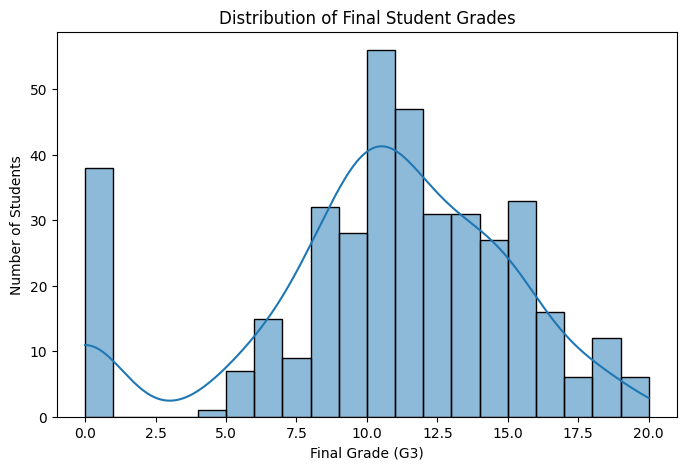

In [7]:
plt.figure(figsize=(8, 5))

sns.histplot(df["G3"], bins=20, kde=True)

plt.title("Distribution of Final Student Grades")
plt.xlabel("Final Grade (G3)")
plt.ylabel("Number of Students")

plt.show()

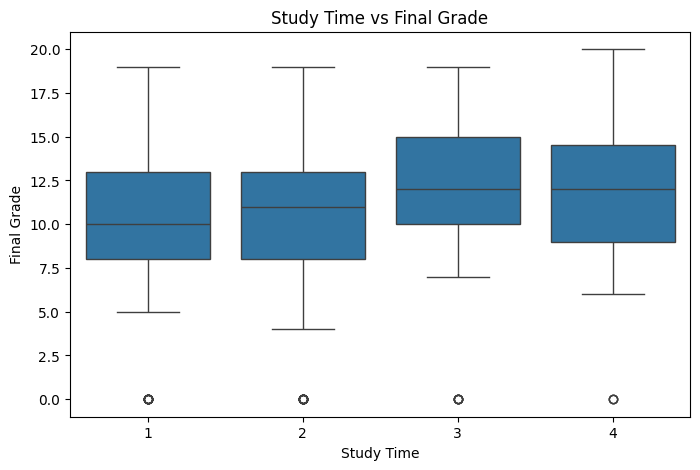

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(x="studytime", y="G3", data=df)

plt.title("Study Time vs Final Grade")
plt.xlabel("Study Time")
plt.ylabel("Final Grade")

plt.show()

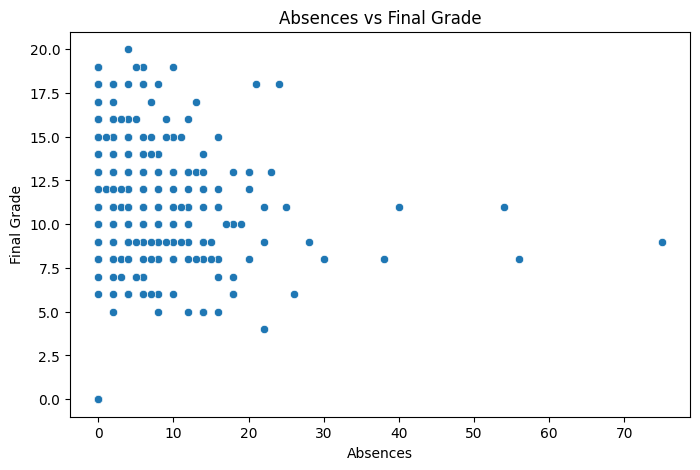

In [10]:
plt.figure(figsize=(8, 5))

sns.scatterplot(x="absences", y="G3", data=df)

plt.title("Absences vs Final Grade")
plt.xlabel("Absences")
plt.ylabel("Final Grade")

plt.show()

Correlation Analysis

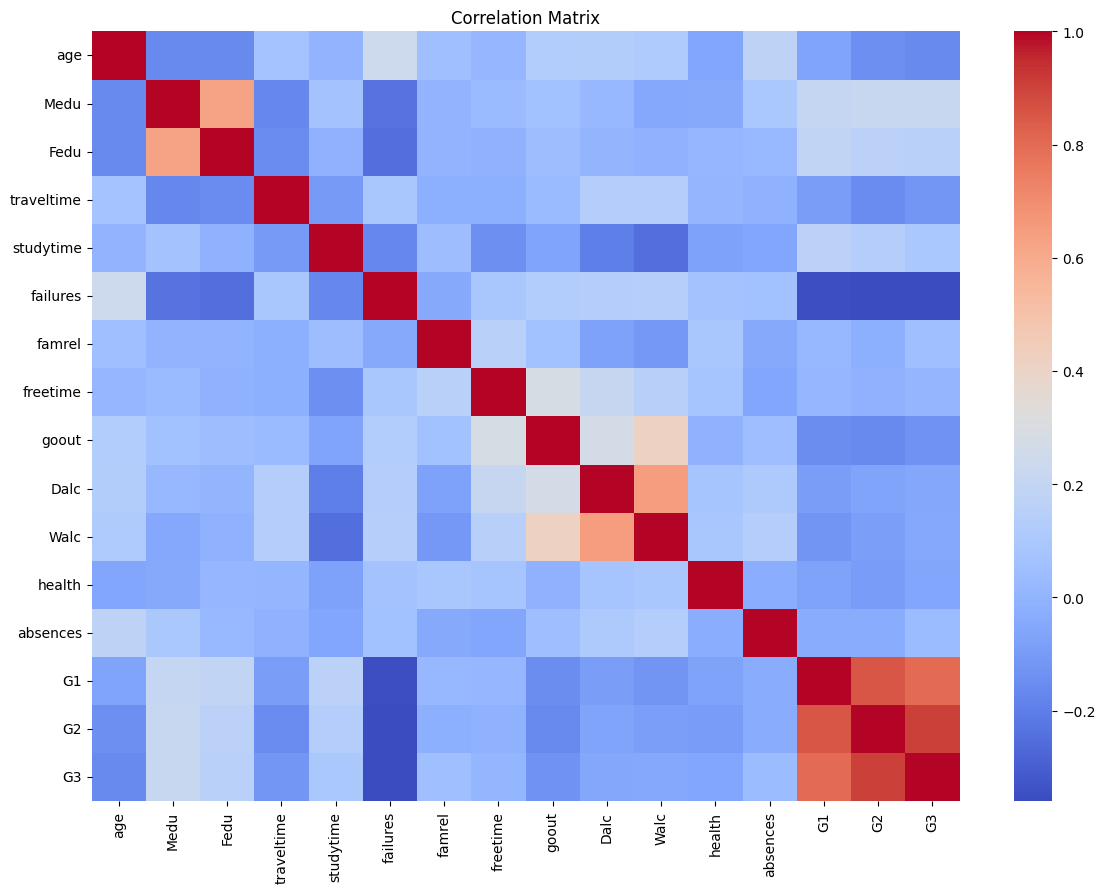

In [11]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14, 10))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")

plt.show()

In [12]:
plt.savefig("results/correlation_matrix.png", dpi=300)

<Figure size 640x480 with 0 Axes>

In [13]:
X = df.drop(columns=["G3"])
y = df["G3"]

print(X.shape)
print(y.shape)

(395, 32)
(395,)


One Hot Encoding

In [14]:
X = pd.get_dummies(X, drop_first=True)

print(X.shape)
print(X.head())

(395, 41)
   age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  goout  \
0   18     4     4           2          2         0       4         3      4   
1   17     1     1           1          2         0       5         3      3   
2   15     1     1           1          2         3       4         3      2   
3   15     4     2           1          3         0       3         2      2   
4   16     3     3           1          2         0       4         3      2   

   Dalc  ...  guardian_mother  guardian_other  schoolsup_yes  famsup_yes  \
0     1  ...             True           False           True       False   
1     1  ...            False           False          False        True   
2     2  ...             True           False           True       False   
3     1  ...             True           False          False        True   
4     1  ...            False           False          False        True   

   paid_yes  activities_yes  nursery_yes  higher_yes

Train/Test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Feature scaling

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

ANN

In [17]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1)
])

c:\Users\nitya\envs\ai-env\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,313 (20.75 KB)

 Trainable params: 5,313 (20.75 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 134.5496 - mae: 10.6173 - val_loss: 123.9196 - val_mae: 10.3599
Epoch 2/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 121.5761 - mae: 10.0451 - val_loss: 114.4594 - val_mae: 9.9667
Epoch 3/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 109.6018 - mae: 9.5599 - val_loss: 97.9987 - val_mae: 9.2268
Epoch 4/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 87.6567 - mae: 8.5596 - val_loss: 68.8156 - val_mae: 7.6946
Epoch 5/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 56.5429 - mae: 6.7631 - val_loss: 33.1224 - val_mae: 5.1296
Epoch 6/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 25.5196 - mae: 4.2805 - val_loss: 13.1210 - val_mae: 2.8099
Epoch 7/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15.0102 - mae: 2.8794 - val_loss: 9.6359 - val_mae: 2.2295
Epoch 8/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 13.4208 - mae: 2.7997 - val_loss: 8.1189 - val_mae: 2.0764
Epoch 9/200
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s

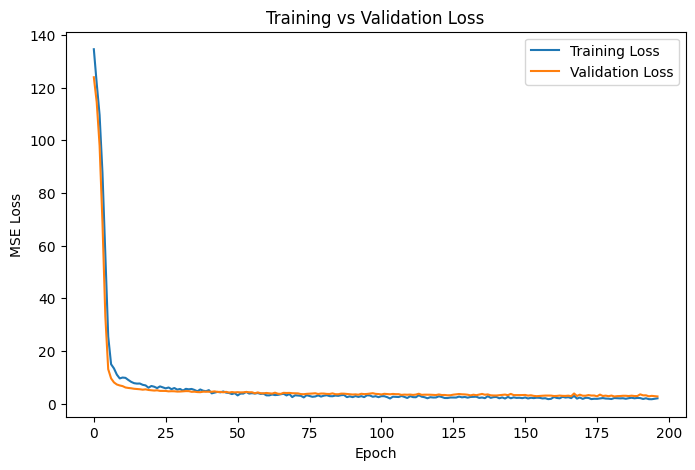

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig("results/loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
y_pred = model.predict(X_test)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [23]:
y_pred = y_pred.flatten()

In [24]:
print(y_pred[:10])

[ 6.4179626 13.069195   2.1926432 10.91094   10.610172  11.140131
 18.033916   7.659654   7.2477317 12.410976 ]


Evaluating the Model

In [25]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred) 

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 1.7752944231033325
MSE : 5.906094551086426
RMSE: 2.4302457799750266
R²  : 0.7119687795639038


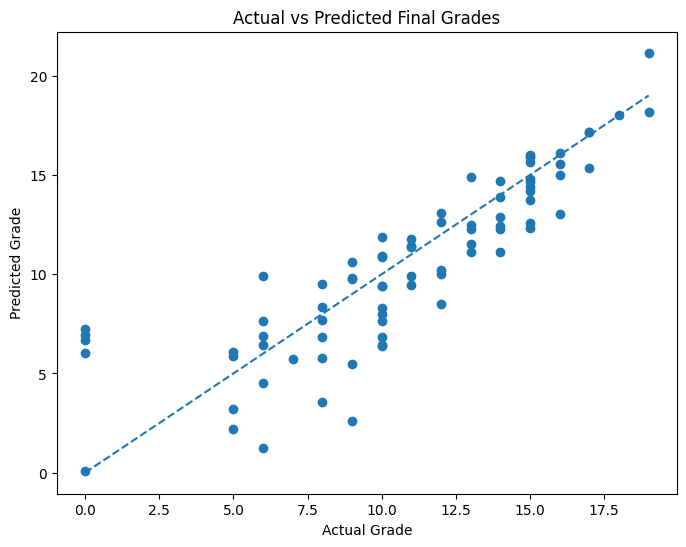

In [30]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Grade")
plt.ylabel("Predicted Grade")
plt.title("Actual vs Predicted Final Grades")
plt.savefig("results/actual_vs_predicted.png",dpi=300,bbox_inches="tight")
plt.show()

In [27]:
model.save("model/student_ann.keras")

Sample Prediction

In [28]:
sample = X_test[0].reshape(1, -1)

prediction = model.predict(sample)

print("Predicted Final Grade:", prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Final Grade: 6.417962


In [29]:
def result_category(grade):
    if grade >= 10:
        return "Pass"
    else:
        return "Fail"
predicted_grade = prediction[0][0]

print("Predicted Grade:", round(predicted_grade, 2))
print("Result:", result_category(predicted_grade))

Predicted Grade: 6.42
Result: Fail


## __Project Conclusion__

The developed **Artificial Neural Network (ANN)** model successfully predicts students' final mathematics grade (`G3`) using the available demographic, academic, social and behavioral attributes, including the previous grades (`G1` and `G2`).

The final model achieved the following performance on the test dataset:

| Evaluation Metric | Value |
|---|---:|
| **Mean Absolute Error (MAE)** | **1.7753** |
| **Mean Squared Error (MSE)** | **5.9061** |
| **Root Mean Squared Error (RMSE)** | **2.4302** |
| **R² Score** | **0.7120 (71.20%)** |

### Inference

- The **MAE of 1.7753** indicates that the predicted final grades differ from the actual grades by approximately **1.78 grade points on average**.
- The **RMSE of 2.4302** indicates the overall magnitude of prediction errors, with larger errors receiving greater weight.
- The **R² score of 0.7120** indicates that the model explains approximately **71.2% of the variation in students' final mathematics grades** in the test dataset.
- The Actual vs. Predicted plot provides a visual comparison between the model's predictions and the actual final grades.
- The training and validation loss curves provide insight into the model's learning behavior during training.

### Final Output

The final output of the project is a **predicted final mathematics grade for a student**, together with quantitative evaluation metrics that measure the performance of the ANN regression model.

Overall, the results demonstrate that the developed ANN model can learn meaningful relationships between the available student attributes and final academic performance and can provide useful estimates of students' final mathematics grades.

> **Note:** Since `G1` and `G2` are included as input features in the final model, the prediction represents a scenario where these previous grades are already available when predicting `G3`.